In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from os.path import curdir

In [14]:
# Question 1a

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

# Loading the specific sheet, skipping the first 16 rows
island_airport_weather = pd.read_excel(
    xl_path, 
    sheet_name='Island Airport Weather', 
    header=16  # Row 17 is index 16
)

# Preview the data
#island_airport_weather.head()

# Validate Type
#island_airport_weather.dtypes

In [15]:
# Question 1a continued

# Calculate air density using the provided formula
# Formula: (Stn Press * 1000) / (287.05 * (Temp + 273.15))
island_airport_weather['Air_Density'] = (island_airport_weather['Stn Press (kPa)'] * 1000) / (287.05 * (island_airport_weather['Temp (°C)'] + 273.15))

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Stn Press (kPa)', 'Temp (°C)', 'Air_Density']].head()

,Stn Press (kPa),Temp (°C),Air_Density
0,98.49,4.3,1.236659
1,98.47,5.1,1.232853
2,98.57,5.9,1.230567
3,98.98,3.3,1.247307
4,99.29,2.8,1.253480


In [16]:
# Question 1b

# Convert wind speed from km/h to m/s
island_airport_weather['Wind_Spd_ms'] = island_airport_weather['Wind Spd (km/h)'] * 0.277778

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Wind Spd (km/h)', 'Wind_Spd_ms']].head()

,Wind Spd (km/h),Wind_Spd_ms
0,11,3.055558
1,4,1.111112
2,28,7.777784
3,34,9.444452
4,28,7.777784


In [20]:
# Question 1c

# Loading the specific sheet
turbine_specs = pd.read_excel(
    xl_path, 
    sheet_name='Turbine Specifications'
)

# Preview the data
turbine_specs.head()

# Validate Type
#turbine_specs.dtypes

,Field,Comments,Values,Units
0,Wind facility name/ID,The name of the wind facility,Toronto Wind One,NaN
1,Number of turbines,Number of turbines at this facility,49,NaN
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN


In [25]:
# Question 1c continued

# 1. Extract and convert values from turbine_specs
cut_in = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-in windspeed (m/s)', 'Values'].values[0])
cut_out = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-out windspeed (m/s)', 'Values'].values[0])
max_cp = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Maximum power coefficient', 'Values'].values[0])
swept_area = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine swept area', 'Values'].values[0])
nominal_power_mw = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine nominal power', 'Values'].values[0])
nominal_power_watts = nominal_power_mw * 1000000

# print(cut_in)
# print(cut_out)
# print(max_cp)
# print(swept_area)
# print(nominal_power_mw)
# print(nominal_power_watts)

# 2. Calculate the baseline power using the formula
# power = Air_Density * Swept_Area * 0.5 * (Wind_Spd_ms^3) * Max_Cp
island_airport_weather['Power_Watts'] = island_airport_weather['Air_Density'] * swept_area * 0.5 * (island_airport_weather['Wind_Spd_ms'] ** 3) * max_cp

# 3. Apply the constraints using np.where
# Condition 1: If wind is below cut-in OR above cut-out, power is 0
island_airport_weather['Power_Watts'] = np.where(
    (island_airport_weather['Wind_Spd_ms'] < cut_in) | (island_airport_weather['Wind_Spd_ms'] > cut_out), 
    0, 
    island_airport_weather['Power_Watts']
)

# Condition 2: Cap the power at the turbine's nominal maximum capacity
island_airport_weather['Power_Watts'] = np.where(
    island_airport_weather['Power_Watts'] > nominal_power_watts, 
    nominal_power_watts, 
    island_airport_weather['Power_Watts']
)

# Print out the first 5 records
island_airport_weather[['Wind_Spd_ms', 'Air_Density', 'Power_Watts']].head()

,Wind_Spd_ms,Air_Density,Power_Watts
0,3.055558,1.236659,0.000000e+00
1,1.111112,1.232853,0.000000e+00
2,7.777784,1.230567,1.344892e+06
3,9.444452,1.247307,2.440722e+06
4,7.777784,1.253480,1.369935e+06


In [26]:
# Question 1d

# 1. Sum up the hourly power produced by a single turbine
total_power_single_turbine_watts = island_airport_weather['Power_Watts'].sum()

# 2. Multiply by the 49 turbines in the windfarm
total_windfarm_power_watts = total_power_single_turbine_watts * 49

# 3. Convert the total power from Watts to Megawatts (divide by 1,000,000)
total_windfarm_power_mw = total_windfarm_power_watts / 1000000

# Print the final result
print(f"Total Electricity Produced for the Windfarm in January: {total_windfarm_power_mw:.2f} MW")

Total Electricity Produced for the Windfarm in January: 43077.82 MW


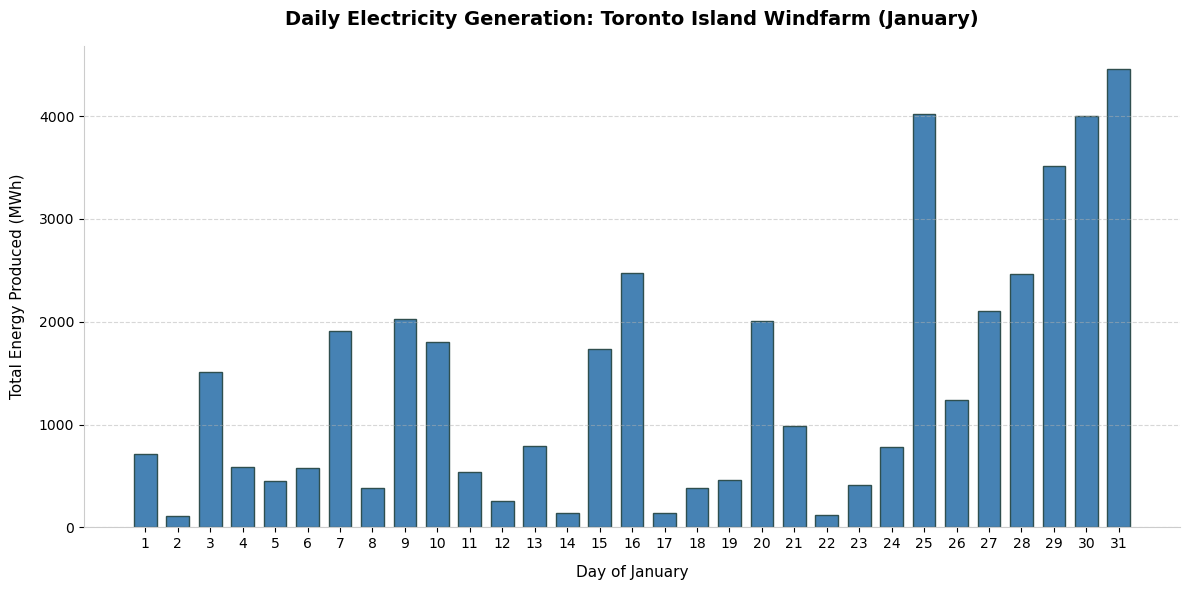

In [29]:
# Question 1e

# 1. Calculate daily windfarm energy production
# Group by the existing 'Day' column, sum the hourly Power_Watts, 
# multiply by 49 turbines, and divide by 1,000,000 to convert to MWh
daily_energy = (island_airport_weather.groupby('Day')['Power_Watts'].sum() * 49) / 1000000

# 2. Create the professional bar chart
# Using subplots to avoid plt.figure() as per best practices
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars in chronological order (Day 1 to 31) with a professional steel blue color
ax.bar(daily_energy.index, daily_energy.values, color='#4682B4', edgecolor='#2F4F4F', width=0.7)

# Title and Labels
ax.set_title('Daily Electricity Generation: Toronto Island Windfarm (January)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Day of January', fontsize=11, labelpad=10)
ax.set_ylabel('Total Energy Produced (MWh)', fontsize=11, labelpad=10)

# Clean up chart borders (Spines) to reduce visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle horizontal gridlines for easier value reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure the x-axis displays every single day from 1 to 31 clearly without overlapping
ax.set_xticks(daily_energy.index)

# Adjust layout and save the image file
plt.tight_layout()
plt.show()

In [ ]:
# Question 3

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from os.path import curdir

In [ ]:
# 3a

# Loading data into df

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

sales = pd.read_excel(
    xl_path, 
    sheet_name='Product_Sales',
    index_col='Obs'
)

# See what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,1,1162.91,235.19,1,5,$67.18
2,2,1191.11,944.87,1,3,$54.56
3,3,1214.96,737.06,0,5,$58.85
4,4,1336.07,986.15,0,7,$56.48
5,5,1343.29,871.33,1,7,$58.74


In [ ]:
# Evaluating data types
sales.dtypes

Product_ID         int64
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price             object
dtype: object

In [ ]:
# What is the largest product ID because that will define how many 0's we need to add ahead of the other values
sales["Product_ID"].max()

200

In [7]:
# Convert product id to string and add zeros to length of 3
sales['Product_ID'] = sales['Product_ID'].astype(str).str.zfill(3)

# Verify results
print(sales['Product_ID'].dtypes)
print(sales[['Product_ID']].head())

object
    Product_ID
Obs           
1          001
2          002
3          003
4          004
5          005


In [8]:
# 3b

# Evaluating data types
sales.dtypes

Product_ID        object
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price             object
dtype: object

In [9]:
# Evaluating what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,001,1162.91,235.19,1,5,$67.18
2,002,1191.11,944.87,1,3,$54.56
3,003,1214.96,737.06,0,5,$58.85
4,004,1336.07,986.15,0,7,$56.48
5,005,1343.29,871.33,1,7,$58.74


In [10]:
# Each sales observation for 2016 and 2017 has its own column instead of individual row
# Price is an object and needs to be converted to float

# 1. Melt the dataframe to fix the wide structure
sales_tidy = sales.melt(
    id_vars=['Product_ID', 'Import', 'Num_Retailers', 'Price'], 
    value_vars=['Sales_2016', 'Sales_2017'],
    var_name='Year', 
    value_name='Sales'
)

# Clean up the 'Year' column so it just shows the actual year (e.g., '2016' instead of 'Sales_2016')
sales_tidy['Year'] = sales_tidy['Year'].str.replace('Sales_', '')

# 2. Clean the Price column (remove '$' and convert to float). Note regex here tells python to not use regular expressions which would lead to the last character being deleted instead of the literal $ sign
sales_tidy['Price'] = sales_tidy['Price'].str.replace('$', '', regex=False).astype(float)

# Verify the changes
print(sales_tidy.dtypes)
print(sales_tidy.head())

Product_ID        object
Import             int64
Num_Retailers      int64
Price            float64
Year              object
Sales            float64
dtype: object
  Product_ID  Import  Num_Retailers  Price  Year    Sales
0        001       1              5  67.18  2016  1162.91
1        002       1              3  54.56  2016  1191.11
2        003       0              5  58.85  2016  1214.96
3        004       0              7  56.48  2016  1336.07
4        005       1              7  58.74  2016  1343.29


In [11]:
# Year should be numeric so we can sort by it and use for calculation if needed

sales_tidy['Year'] = sales_tidy['Year'].astype(int)

sales_tidy.dtypes

Product_ID        object
Import             int64
Num_Retailers      int64
Price            float64
Year               int64
Sales            float64
dtype: object

In [15]:
# As additional best practice, even though does not seem to be the case we will drop dupes

# 1. Check the number of rows before
print("Rows before dropping absolute duplicates:", sales_tidy.shape[0])

# 2. Drop rows where entire row is a duplicate, keeping the first occurrence
sales_tidy = sales_tidy.drop_duplicates()

# 3. Check the number of rows after
print("Rows after dropping absolute duplicates:", sales_tidy.shape[0])

Rows before dropping absolute duplicates: 400
Rows after dropping absolute duplicates: 400


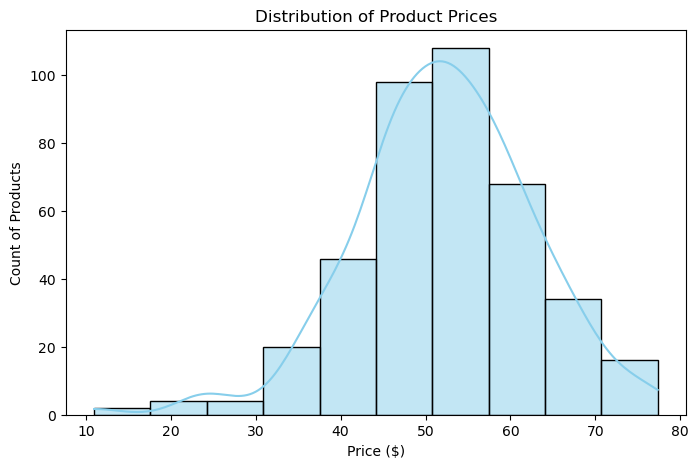

In [ ]:
# 3c

# Histogram is a good way to visualize distribution of pricesabs
# Using seaborn to be able to show smooth trend line and modern look
# We will split prices into 10 bins
# Given there should be 2 records for each price due to tidying activity, we will display 2 variants of graph:
#   1) Price Distribution across the data from 2 years
#   2) Price Distribution of unique price for each product (Essentially rewinding the melt)

# import matplotlib.pyplot as plt
# import seaborn as sns

#3c-1

plt.figure(figsize=(8, 5))
sns.histplot(data=sales_tidy, x='Price', bins=10, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count of Products')
plt.show()

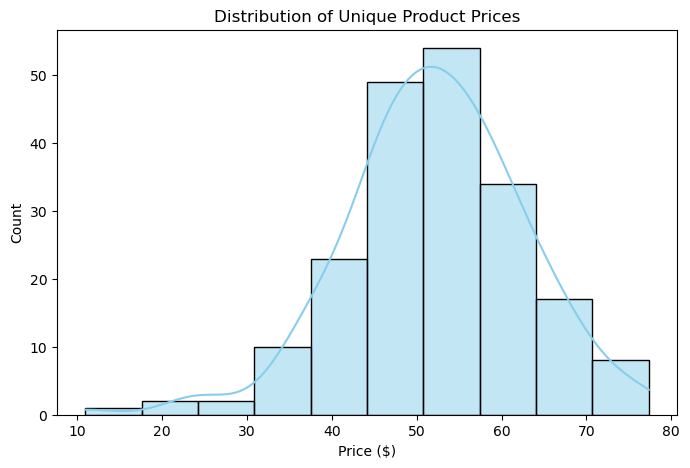

In [16]:
#3c-2
plt.figure(figsize=(8, 5))

# Filter duplicates only if BOTH Product_ID and Price are identical
unique_price_records = sales_tidy.drop_duplicates(subset=['Product_ID', 'Price'])

# Plot using the safe filtered data
sns.histplot(
    data=unique_price_records, 
    x='Price', 
    bins=10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Unique Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

Correlation Matrix:
 [[ 1.         -0.05023465]
 [-0.05023465  1.        ]]

The correlation between Price and Number of Retailers is: -0.0502


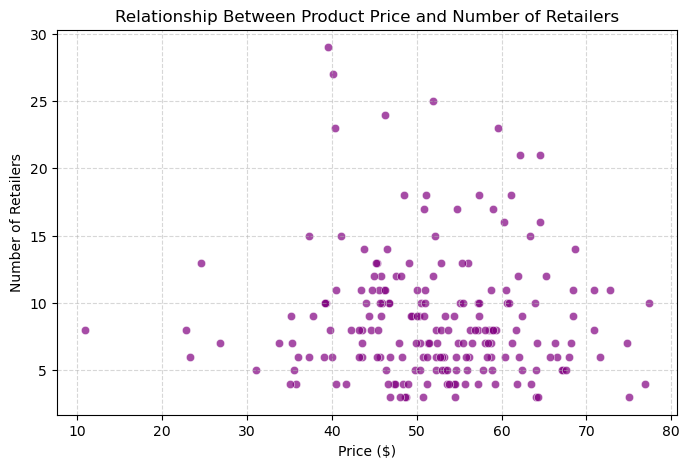

In [ ]:
# 3d

# 1. Calculate the correlation coefficient matrix using numpy
# Using safe unique_price_records so we don't skew the relationship with duplicate rows
correlation_matrix = np.corrcoef(unique_price_records['Price'], unique_price_records['Num_Retailers'])
print("Correlation Matrix:\n", correlation_matrix)

# 2. Identifying the correlation value between Price and Num_Retailers
# (It's at row 0, column 1 in the matrix)
correlation_value = correlation_matrix[0, 1]
print(f"\nThe correlation between Price and Number of Retailers is: {correlation_value:.4f}")

# 3. Creating the scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=unique_price_records, 
    x='Price', 
    y='Num_Retailers', 
    color='purple', 
    alpha=0.7
)

plt.title('Relationship Between Product Price and Number of Retailers')
plt.xlabel('Price ($)')
plt.ylabel('Number of Retailers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#3d Conclusion
print(f"The correlation between Price and Number of Retailers is: {correlation_value:.4f}.\nIn practical terms, a correlation close to zero means there is no meaningful linear relationship\nbetween how much a product costs and how many retailers choose to sell it. For a business owner,\nthis tells us that pricing decisions and distribution expansion are completely independent.\nPricing a product higher or lower won't predictably change how many stores carry it.")

The correlation between Price and Number of Retailers is: -0.0502.
In practical terms, a correlation close to zero means there is no meaningful linear relationship
between how much a product costs and how many retailers choose to sell it. For a business owner,
this tells us that pricing decisions and distribution expansion are completely independent.
Pricing a product higher or lower won't predictably change how many stores carry it.
